# Auditoría del tokenizador de ChemBERTa sobre SLICES

Este notebook mide la compatibilidad entre las cadenas `slices_string` y el tokenizador actual de `seyonec/ChemBERTa-zinc-base-v1`. La auditoría responde tres preguntas:

1. ¿Qué tokens léxicos de SLICES reconoce como una sola unidad?
2. ¿Cuánto crece cada secuencia después de la tokenización?
3. ¿Qué tokens producen desconocidos o fragmentación innecesaria?

> **Criterio:** un token SLICES se considera reconocido cuando su contenido genera exactamente un token del modelo y no `<unk>`. En un tokenizador byte-level puede no haber desconocidos y aun así existir mucha fragmentación. Por eso `<unk>` y fragmentación se reportan por separado.

In [1]:
from collections import Counter, defaultdict
from pathlib import Path
import platform
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import transformers
from IPython.display import display
from transformers import AutoTokenizer

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 30)

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'semiconductores_listos_con_slices.csv').exists():
            return candidate
    raise FileNotFoundError('No se encontró la raíz del proyecto ni el CSV de SLICES.')

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / 'data' / 'semiconductores_listos_con_slices.csv'
OUTPUT_DIR = PROJECT_ROOT / 'transferability' / 'audit' / 'results' / 'tokenizer'
CACHE_DIR = PROJECT_ROOT / '.cache' / 'huggingface'

MODEL_NAME = 'seyonec/ChemBERTa-zinc-base-v1'
MODEL_REVISION = '761d6a18cf99db371e0b43baf3e2d21b3e865a20'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME, revision=MODEL_REVISION, cache_dir=CACHE_DIR
)

print(f'Python: {platform.python_version()}')
print(f'transformers: {transformers.__version__}')
print(f'Tokenizador: {type(tokenizer).__name__}')
print(f'Modelo: {MODEL_NAME}@{MODEL_REVISION[:12]}')
print(f'Vocabulario: {tokenizer.vocab_size:,}')
print(f'Longitud máxima: {tokenizer.model_max_length:,}')
print(f'Tokens especiales: {tokenizer.special_tokens_map}')

Python: 3.10.21
transformers: 5.17.0
Tokenizador: RobertaTokenizer
Modelo: seyonec/ChemBERTa-zinc-base-v1@761d6a18cf99
Vocabulario: 767
Longitud máxima: 512
Tokens especiales: {'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}


## 1. Cargar y normalizar las secuencias

Se normalizan espacios para que la comparación mida el lenguaje SLICES y no diferencias accidentales de formato. El CSV original no se modifica.

In [2]:
required_columns = ['material_id', 'formula_pretty', 'slices_string']
data = pd.read_csv(DATA_PATH, usecols=required_columns)

if data['material_id'].duplicated().any():
    raise ValueError('material_id debe ser único para auditar secuencias individualmente.')
if data['slices_string'].isna().any():
    raise ValueError('Hay valores nulos en slices_string.')

data['slices_normalized'] = data['slices_string'].astype(str).str.split().str.join(' ')
if data['slices_normalized'].eq('').any():
    raise ValueError('Hay cadenas SLICES vacías después de normalizar espacios.')

lexical_lengths = data['slices_normalized'].str.split().str.len()
dataset_overview = pd.DataFrame({
    'métrica': ['secuencias', 'secuencias únicas', 'tokens léxicos totales',
                'tokens léxicos únicos', 'mínimo por secuencia', 'mediana por secuencia',
                'máximo por secuencia'],
    'valor': [
        len(data), data['slices_normalized'].nunique(), int(lexical_lengths.sum()),
        len({token for value in data['slices_normalized'] for token in value.split()}),
        int(lexical_lengths.min()), float(lexical_lengths.median()), int(lexical_lengths.max()),
    ],
})
display(dataset_overview)
display(data[required_columns].head(3))

,métrica,valor
0,secuencias,2036.0
1,secuencias únicas,2036.0
2,tokens léxicos totales,202084.0
3,tokens léxicos únicos,131.0
4,mínimo por secuencia,3.0
5,mediana por secuencia,98.0
6,máximo por secuencia,308.0


,material_id,formula_pretty,slices_string
0,mp-861884,AcGaTe2,Ac Ga Te Te 0 2 ooo 0 2 +oo 0 2 oo+ 0 2 o+o 0 3 -oo 0 3 oo- 0 3 o-o 0 3 ooo
1,mp-861460,AcInTe2,Ac In Te Te 0 2 oo+ 0 2 o+o 0 2 +oo 0 2 ooo 0 3 o-o 0 3 ooo 0 3 -oo 0 3 oo- 0 1 ++o 0 1 o++ 0 1 +o+ 0 1 +oo 0 1 oo+ ...
2,mp-1215080,Ag12SBr,Ag Ag Ag Ag Ag Ag Ag Ag Ag Ag Ag Ag S Br 0 11 oo- 0 10 ooo 1 10 +oo 1 11 +o- 2 9 -oo 2 7 ooo 3 6 ooo 3 8 oo- 4 9 -+o...


## 2. Tabla de cobertura por token SLICES

La columna `piezas_con_espacio` reproduce el contexto habitual dentro de una secuencia. En RoBERTa, `Ġ` representa un espacio. `costo_extra_corpus` pondera la fragmentación por la frecuencia real del token, lo que permite priorizar cambios de vocabulario.

In [3]:
ELEMENT_RE = re.compile(r'^[A-Z][a-z]?$')
INDEX_RE = re.compile(r'^\d+$')
TRANSLATION_RE = re.compile(r'^[+o-]{3}$')

def token_type(token: str) -> str:
    if ELEMENT_RE.fullmatch(token):
        return 'elemento'
    if INDEX_RE.fullmatch(token):
        return 'índice'
    if TRANSLATION_RE.fullmatch(token):
        return 'traslación'
    return 'otro'

occurrences = Counter()
sequence_occurrences = Counter()
first_examples = defaultdict(list)
first_position_occurrences = Counter()

for row in data.itertuples(index=False):
    lexical_tokens = row.slices_normalized.split()
    occurrences.update(lexical_tokens)
    sequence_occurrences.update(set(lexical_tokens))
    first_position_occurrences[lexical_tokens[0]] += 1
    for token in set(lexical_tokens):
        if len(first_examples[token]) < 3:
            first_examples[token].append(row.material_id)

vocabulary = tokenizer.get_vocab()
unk = tokenizer.unk_token
token_rows = []

for token, frequency in occurrences.items():
    content_pieces = tokenizer.tokenize(token)
    spaced_pieces = tokenizer.tokenize(' ' + token)
    unknown = unk in content_pieces or unk in spaced_pieces
    recognized = len(content_pieces) == 1 and not unknown
    first_count = first_position_occurrences[token]
    nonfirst_count = frequency - first_count
    actual_piece_total = first_count * len(content_pieces) + nonfirst_count * len(spaced_pieces)
    extra_content = max(len(content_pieces) - 1, 0)
    reasons = []
    if unknown:
        reasons.append('desconocido')
    if len(content_pieces) > 1:
        reasons.append('fragmentado')
    if len(spaced_pieces) > len(content_pieces):
        reasons.append('separador adicional')

    token_rows.append({
        'token_slices': token,
        'tipo': token_type(token),
        'apariciones': frequency,
        'secuencias': sequence_occurrences[token],
        'en_vocabulario_exacto': token in vocabulary,
        'en_vocabulario_con_espacio': ('Ġ' + token) in vocabulary,
        'reconocido_como_unidad': recognized,
        'contiene_unk': unknown,
        'n_piezas_contenido': len(content_pieces),
        'piezas_contenido': ' '.join(content_pieces),
        'n_piezas_con_espacio': len(spaced_pieces),
        'piezas_con_espacio': ' '.join(spaced_pieces),
        'piezas_extra_contenido_por_aparición': extra_content,
        'piezas_extra_contenido_corpus': extra_content * frequency,
        'piezas_modelo_atribuidas_corpus': actual_piece_total,
        'problema': ', '.join(reasons) if reasons else 'ninguno',
        'ejemplos_material_id': ', '.join(first_examples[token]),
    })

token_table = (pd.DataFrame(token_rows)
               .sort_values(['reconocido_como_unidad', 'piezas_extra_contenido_corpus', 'apariciones'],
                            ascending=[True, False, False])
               .reset_index(drop=True))

display(token_table)

,token_slices,tipo,apariciones,secuencias,en_vocabulario_exacto,en_vocabulario_con_espacio,reconocido_como_unidad,contiene_unk,n_piezas_contenido,piezas_contenido,n_piezas_con_espacio,piezas_con_espacio,piezas_extra_contenido_por_aparición,piezas_extra_contenido_corpus,piezas_modelo_atribuidas_corpus,problema,ejemplos_material_id
0,ooo,traslación,26085,1987,False,False,False,False,3,o o o,4,Ġ o o o,2,52170,104340,"fragmentado, separador adicional","mp-861884, mp-861460, mp-1215080"
1,-oo,traslación,5142,1668,False,False,False,False,3,- o o,4,Ġ - o o,2,10284,20568,"fragmentado, separador adicional","mp-861884, mp-861460, mp-1215080"
2,o-o,traslación,5120,1741,False,False,False,False,3,o - o,4,Ġ o - o,2,10240,20480,"fragmentado, separador adicional","mp-861884, mp-861460, mp-4691"
3,+oo,traslación,4275,1543,False,False,False,False,3,+ o o,4,Ġ + o o,2,8550,17100,"fragmentado, separador adicional","mp-861884, mp-861460, mp-1215080"
4,oo-,traslación,4092,1571,False,False,False,False,3,o o -,4,Ġ o o -,2,8184,16368,"fragmentado, separador adicional","mp-861884, mp-861460, mp-1215080"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,H,elemento,126,37,True,False,True,False,1,H,2,Ġ H,0,0,251,separador adicional,"mp-1008506, mp-568177, mp-1018093"
127,Y,elemento,110,53,True,False,True,False,1,Y,2,Ġ Y,0,0,191,separador adicional,"mp-1236492, mp-1189739, mp-1106096"
128,B,elemento,50,17,True,False,True,False,1,B,2,Ġ B,0,0,99,separador adicional,"mp-1228446, mp-1106370, mp-10289"
129,Sc,elemento,43,20,True,False,True,False,1,Sc,2,Ġ Sc,0,0,75,separador adicional,"mp-1247344, mp-962070, mp-1100438"


## 3. Crecimiento por secuencia

`factor_crecimiento` compara tokens del modelo sin especiales contra tokens léxicos SLICES. `excede_limite` usa la longitud máxima del tokenizador e incluye los tokens especiales que ChemBERTa añade.

In [4]:
special_token_count = tokenizer.num_special_tokens_to_add(pair=False)
model_max_length = int(tokenizer.model_max_length)
sequence_rows = []

for row in data.itertuples(index=False):
    lexical_tokens = row.slices_normalized.split()
    model_ids = tokenizer.encode(row.slices_normalized, add_special_tokens=False)
    model_tokens = tokenizer.convert_ids_to_tokens(model_ids)
    with_specials = len(model_ids) + special_token_count
    available_content = max(model_max_length - special_token_count, 0)
    sequence_rows.append({
        'material_id': row.material_id,
        'formula_pretty': row.formula_pretty,
        'tokens_slices': len(lexical_tokens),
        'tokens_chemberta_sin_especiales': len(model_ids),
        'tokens_chemberta_con_especiales': with_specials,
        'crecimiento_absoluto': len(model_ids) - len(lexical_tokens),
        'factor_crecimiento': len(model_ids) / len(lexical_tokens),
        'tokens_unk': sum(piece == unk for piece in model_tokens),
        'excede_limite': with_specials > model_max_length,
        'tokens_fuera_del_limite': max(with_specials - model_max_length, 0),
        'fracción_contenido_retenible': min(available_content / len(model_ids), 1.0),
        'slices_string': row.slices_normalized,
    })

sequence_table = pd.DataFrame(sequence_rows)

# Verificación: la tokenización completa debe coincidir con la suma por token/contexto.
for value, observed in zip(data['slices_normalized'], sequence_table['tokens_chemberta_sin_especiales']):
    parts = value.split()
    reconstructed = len(tokenizer.tokenize(parts[0])) + sum(
        len(tokenizer.tokenize(' ' + token)) for token in parts[1:]
    )
    if reconstructed != observed:
        raise AssertionError(f'Conteo contextual inconsistente para: {value[:80]}')

display(sequence_table.sort_values('tokens_chemberta_con_especiales', ascending=False).head(25))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (891 > 512). Running this sequence through the model will result in indexing errors


,material_id,formula_pretty,tokens_slices,tokens_chemberta_sin_especiales,tokens_chemberta_con_especiales,crecimiento_absoluto,factor_crecimiento,tokens_unk,excede_limite,tokens_fuera_del_limite,fracción_contenido_retenible,slices_string
1506,mp-1210067,Nd3Cu3Bi4,308,897,899,589,2.912338,0,True,387,0.568562,Nd Nd Nd Nd Nd Nd Cu Cu Cu Cu Cu Cu Bi Bi Bi Bi Bi Bi Bi Bi 0 9 oo- 0 8 o+o 0 11 -oo 0 10 ooo 0 19 ooo 0 16 o+o 0 17...
587,mp-1189310,Ho3Cu3Sb4,308,897,899,589,2.912338,0,True,387,0.568562,Ho Ho Ho Ho Ho Ho Cu Cu Cu Cu Cu Cu Sb Sb Sb Sb Sb Sb Sb Sb 0 9 o-o 0 8 +oo 0 10 ooo 0 11 oo- 0 12 ooo 0 19 +oo 0 18...
530,mp-1189617,Gd3Cu3Sb4,308,897,899,589,2.912338,0,True,387,0.568562,Gd Gd Gd Gd Gd Gd Cu Cu Cu Cu Cu Cu Sb Sb Sb Sb Sb Sb Sb Sb 0 10 ooo 0 11 oo- 0 9 o-o 0 8 +oo 0 12 ooo 0 18 +oo 0 19...
1019,mp-17926,Zr3Ni3Sb4,308,897,899,589,2.912338,0,True,387,0.568562,Zr Zr Zr Zr Zr Zr Ni Ni Ni Ni Ni Ni Sb Sb Sb Sb Sb Sb Sb Sb 0 6 ooo 0 8 ooo 0 10 -oo 0 9 ooo 0 13 ooo 0 15 o+o 0 14 ...
450,mp-1105955,Er3Cu3Sb4,308,897,899,589,2.912338,0,True,387,0.568562,Er Er Er Er Er Er Cu Cu Cu Cu Cu Cu Sb Sb Sb Sb Sb Sb Sb Sb 0 8 +oo 0 11 oo- 0 10 ooo 0 9 o-o 0 19 +oo 0 12 ooo 0 18...
1505,mp-1105400,Nd3Bi4Au3,308,893,895,585,2.899351,0,True,383,0.571109,Nd Nd Nd Nd Nd Nd Bi Bi Bi Bi Bi Bi Bi Bi Au Au Au Au Au Au 0 18 ooo 0 19 oo- 0 16 +oo 0 17 o-o 0 12 +oo 0 7 oo- 0 6...
531,mp-1188599,Gd3Sb4Au3,308,893,895,585,2.899351,0,True,383,0.571109,Gd Gd Gd Gd Gd Gd Sb Sb Sb Sb Sb Sb Sb Sb Au Au Au Au Au Au 0 19 oo- 0 17 o-o 0 18 ooo 0 16 +oo 0 13 +oo 0 12 +oo 0 ...
1685,mp-1105248,Sm3Bi4Au3,308,893,895,585,2.899351,0,True,383,0.571109,Sm Sm Sm Sm Sm Sm Bi Bi Bi Bi Bi Bi Bi Bi Au Au Au Au Au Au 0 18 ooo 0 16 +oo 0 17 o-o 0 19 oo- 0 13 +oo 0 7 oo- 0 6...
740,mp-1105333,La3Bi4Au3,308,893,895,585,2.899351,0,True,383,0.571109,La La La La La La Bi Bi Bi Bi Bi Bi Bi Bi Au Au Au Au Au Au 0 19 ooo 0 17 ooo 0 18 ooo 0 16 o+o 0 13 ooo 0 7 ooo 0 1...
1561,mp-1105252,Pr3Bi4Au3,308,893,895,585,2.899351,0,True,383,0.571109,Pr Pr Pr Pr Pr Pr Bi Bi Bi Bi Bi Bi Bi Bi Au Au Au Au Au Au 0 17 o-o 0 18 ooo 0 19 oo- 0 16 +oo 0 13 +oo 0 12 +oo 0 ...


## 4. Resumen y tokens problemáticos

La prioridad se ordena por el número total de piezas extra que cada tipo de token introduce en el corpus. Esto favorece problemas frecuentes, no sólo casos raros con mucha fragmentación.

In [5]:
problem_tokens = (token_table.loc[
    token_table['contiene_unk'] | ~token_table['reconocido_como_unidad']
].sort_values(
    ['contiene_unk', 'piezas_extra_contenido_corpus', 'apariciones'],
    ascending=[False, False, False],
).reset_index(drop=True))

summary = pd.DataFrame({
    'métrica': [
        'secuencias auditadas',
        'tipos de token SLICES',
        'tipos reconocidos como una unidad',
        'tipos fragmentados',
        'tipos con <unk>',
        'apariciones con contenido fragmentado',
        'factor de crecimiento medio',
        'factor de crecimiento mediano',
        'factor de crecimiento máximo',
        f'secuencias que exceden {model_max_length} tokens',
        'porcentaje que excede el límite',
    ],
    'valor': [
        len(sequence_table),
        len(token_table),
        int(token_table['reconocido_como_unidad'].sum()),
        int((~token_table['reconocido_como_unidad']).sum()),
        int(token_table['contiene_unk'].sum()),
        int(token_table.loc[~token_table['reconocido_como_unidad'], 'apariciones'].sum()),
        sequence_table['factor_crecimiento'].mean(),
        sequence_table['factor_crecimiento'].median(),
        sequence_table['factor_crecimiento'].max(),
        int(sequence_table['excede_limite'].sum()),
        100 * sequence_table['excede_limite'].mean(),
    ],
})

display(summary)
display(problem_tokens.head(50))

if problem_tokens['contiene_unk'].any():
    print('Hay tokens que producen <unk>; requieren atención inmediata.')
else:
    print('No aparecen <unk>, pero esto no implica compatibilidad: revisa la fragmentación y el crecimiento.')

,métrica,valor
0,secuencias auditadas,2036.000000
1,tipos de token SLICES,131.000000
2,tipos reconocidos como una unidad,29.000000
3,tipos fragmentados,102.000000
4,tipos con <unk>,0.000000
5,apariciones con contenido fragmentado,91983.000000
6,factor de crecimiento medio,2.703044
7,factor de crecimiento mediano,2.690133
8,factor de crecimiento máximo,3.021739
9,secuencias que exceden 512 tokens,143.000000


,token_slices,tipo,apariciones,secuencias,en_vocabulario_exacto,en_vocabulario_con_espacio,reconocido_como_unidad,contiene_unk,n_piezas_contenido,piezas_contenido,n_piezas_con_espacio,piezas_con_espacio,piezas_extra_contenido_por_aparición,piezas_extra_contenido_corpus,piezas_modelo_atribuidas_corpus,problema,ejemplos_material_id
0,ooo,traslación,26085,1987,False,False,False,False,3,o o o,4,Ġ o o o,2,52170,104340,"fragmentado, separador adicional","mp-861884, mp-861460, mp-1215080"
1,-oo,traslación,5142,1668,False,False,False,False,3,- o o,4,Ġ - o o,2,10284,20568,"fragmentado, separador adicional","mp-861884, mp-861460, mp-1215080"
2,o-o,traslación,5120,1741,False,False,False,False,3,o - o,4,Ġ o - o,2,10240,20480,"fragmentado, separador adicional","mp-861884, mp-861460, mp-4691"
3,+oo,traslación,4275,1543,False,False,False,False,3,+ o o,4,Ġ + o o,2,8550,17100,"fragmentado, separador adicional","mp-861884, mp-861460, mp-1215080"
4,oo-,traslación,4092,1571,False,False,False,False,3,o o -,4,Ġ o o -,2,8184,16368,"fragmentado, separador adicional","mp-861884, mp-861460, mp-1215080"
5,o+o,traslación,3964,1531,False,False,False,False,3,o + o,4,Ġ o + o,2,7928,15856,"fragmentado, separador adicional","mp-861884, mp-861460, mp-1215080"
6,oo+,traslación,2983,1332,False,False,False,False,3,o o +,4,Ġ o o +,2,5966,11932,"fragmentado, separador adicional","mp-861884, mp-861460, mp-4691"
7,10,índice,4894,1204,False,False,False,False,2,1 0,3,Ġ 1 0,1,4894,14682,"fragmentado, separador adicional","mp-1215080, mp-1215073, mp-4691"
8,11,índice,4789,1172,False,False,False,False,2,1 1,3,Ġ 1 1,1,4789,14367,"fragmentado, separador adicional","mp-1215080, mp-1215073, mp-4691"
9,14,índice,3084,737,False,False,False,False,2,1 4,3,Ġ 1 4,1,3084,9252,"fragmentado, separador adicional","mp-1229141, mp-29816, mp-9538"


No aparecen <unk>, pero esto no implica compatibilidad: revisa la fragmentación y el crecimiento.


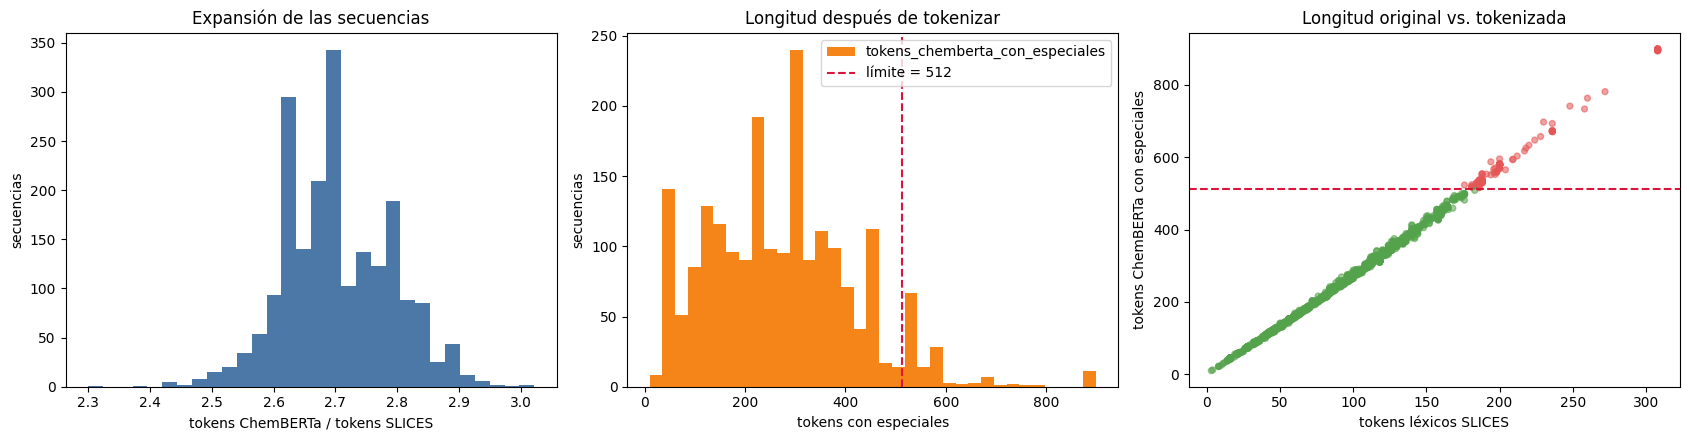

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sequence_table['factor_crecimiento'].plot.hist(bins=30, ax=axes[0], color='#4C78A8')
axes[0].set(title='Expansión de las secuencias', xlabel='tokens ChemBERTa / tokens SLICES', ylabel='secuencias')

sequence_table['tokens_chemberta_con_especiales'].plot.hist(bins=35, ax=axes[1], color='#F58518')
axes[1].axvline(model_max_length, color='crimson', linestyle='--', label=f'límite = {model_max_length}')
axes[1].set(title='Longitud después de tokenizar', xlabel='tokens con especiales', ylabel='secuencias')
axes[1].legend()

colors = np.where(sequence_table['excede_limite'], '#E45756', '#54A24B')
axes[2].scatter(sequence_table['tokens_slices'], sequence_table['tokens_chemberta_con_especiales'],
                c=colors, alpha=0.55, s=18)
axes[2].axhline(model_max_length, color='crimson', linestyle='--')
axes[2].set(title='Longitud original vs. tokenizada', xlabel='tokens léxicos SLICES',
            ylabel='tokens ChemBERTa con especiales')

plt.tight_layout()
plt.show()

## 5. Exportar tablas

Las tablas completas se guardan junto al notebook para análisis posterior.

In [7]:
exports = {
    'resumen.csv': summary,
    'cobertura_tokens.csv': token_table,
    'tokens_problematicos.csv': problem_tokens,
    'crecimiento_secuencias.csv': sequence_table,
}

for filename, table in exports.items():
    path = OUTPUT_DIR / filename
    table.to_csv(path, index=False)
    print(f'{filename}: {len(table):,} filas -> {path.relative_to(PROJECT_ROOT)}')

resumen.csv: 11 filas -> transferability/audit/results/tokenizer/resumen.csv
cobertura_tokens.csv: 131 filas -> transferability/audit/results/tokenizer/cobertura_tokens.csv
tokens_problematicos.csv: 102 filas -> transferability/audit/results/tokenizer/tokens_problematicos.csv
crecimiento_secuencias.csv: 2,036 filas -> transferability/audit/results/tokenizer/crecimiento_secuencias.csv


## Cómo interpretar el resultado

- `<unk> = 0` sólo indica que el tokenizador puede representar todos los caracteres; no dice que comprenda la gramática de SLICES.
- Una pieza por token SLICES conserva mejor sus unidades semánticas. Varias piezas aumentan costo, longitud y dificultad de aprendizaje.
- Las secuencias por encima de 512 tokens serán truncadas por el modelo si no se cambia la estrategia de entrada.
- `piezas_extra_contenido_corpus` ayuda a escoger tokens candidatos al ampliar o reentrenar el vocabulario.
- 2,036 SLICES
- 131 tipos de tokens SLICES
- solo 29/131 son reconocidos como una unidad
- 102/131 están fragmentados
- 0 `<unk>`
- 91,983 apariciones contienen fragmentación
- longitud promedio × 2.70
- 143 secuencias (7.02%) ya exceden 512 tokens
- ninguno de los 27 vectores de traslación es reconocido como unidad
- 67 elementos químicos están fragmentados
- índices `10, 11, 14–19` están fragmentados
